# 03. Feature Engineering - создание новых признаков

## Импорт библиотек

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import phik

## Загрузка данных и предобработка

In [2]:
# Добавляем корневую папку проекта в sys.path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.data_loader import DataLoader

In [3]:
# Загружаем датасет
PROJECT_ROOT = project_root
DATASET_PATH = PROJECT_ROOT / "datasets" / "Credit Risk Data.csv"
KAGGLE_DS = "alexdister/credit-risk-dataset"

df = DataLoader.load(DATASET_PATH, KAGGLE_DS)

In [4]:
from src.preprocess import Preprocessor

prep = Preprocessor()
df = prep.fit_transform(df)

print(f"Размер после обработки: {df.shape}")
print(f"Пропуски: {df.isnull().sum().sum()}")

Размер после обработки: (32574, 24)
Пропуски: 0


In [5]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,education_level,city,employment_type,loan_term_months,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies,emp_length_missing
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,...,Master,Toronto,Full-time,36,1607.802794,0.271646,10,0.585436,3,0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,...,Master,Swansea,Full-time,36,2760.505633,0.860469,14,0.750732,0,0
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,...,Bachelor,Vancouver,Part-time,12,7155.286150,0.643592,15,0.379333,0,0
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,...,Bachelor,Buffalo,Part-time,36,15626.153440,0.930628,4,0.228103,0,0
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,...,High School,San Francisco,Full-time,36,2211.741134,0.475933,10,0.827034,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 32574 entries, 1 to 32580
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32574 non-null  int64  
 1   person_income               32574 non-null  int64  
 2   person_home_ownership       32574 non-null  str    
 3   person_emp_length           32574 non-null  float64
 4   loan_intent                 32574 non-null  str    
 5   loan_grade                  32574 non-null  str    
 6   loan_amnt                   32574 non-null  int64  
 7   loan_int_rate               32574 non-null  float64
 8   loan_status                 32574 non-null  int64  
 9   loan_percent_income         32574 non-null  float64
 10  cb_person_default_on_file   32574 non-null  str    
 11  cb_person_cred_hist_length  32574 non-null  int64  
 12  gender                      32574 non-null  str    
 13  marital_status              32574 non-null  str

## Анализ признаков

In [7]:
# Разделение признаков по типам

# Целевая переменная
target = "loan_status"

# Все колонки, кроме целевой
features = df.columns.drop(target).tolist()

numeric_continuous = []
numeric_categorical = []
categorical_str = []

for col in features:
    dtype = df[col].dtype
    n_unique = df[col].nunique()
    if dtype in ["int64", "float64"]:
        if n_unique > 10:
            numeric_continuous.append(col)
        else:
            numeric_categorical.append(col)
    elif dtype == "str":
        categorical_str.append(col)

print("Числовые непрерывные признаки:", numeric_continuous)
print("Числовые категориальные признаки (<=10 уникальных):", numeric_categorical)
print("Строковые категориальные признаки:", categorical_str)

Числовые непрерывные признаки: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'other_debt', 'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio']
Числовые категориальные признаки (<=10 уникальных): ['loan_term_months', 'past_delinquencies', 'emp_length_missing']
Строковые категориальные признаки: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'gender', 'marital_status', 'education_level', 'city', 'employment_type']


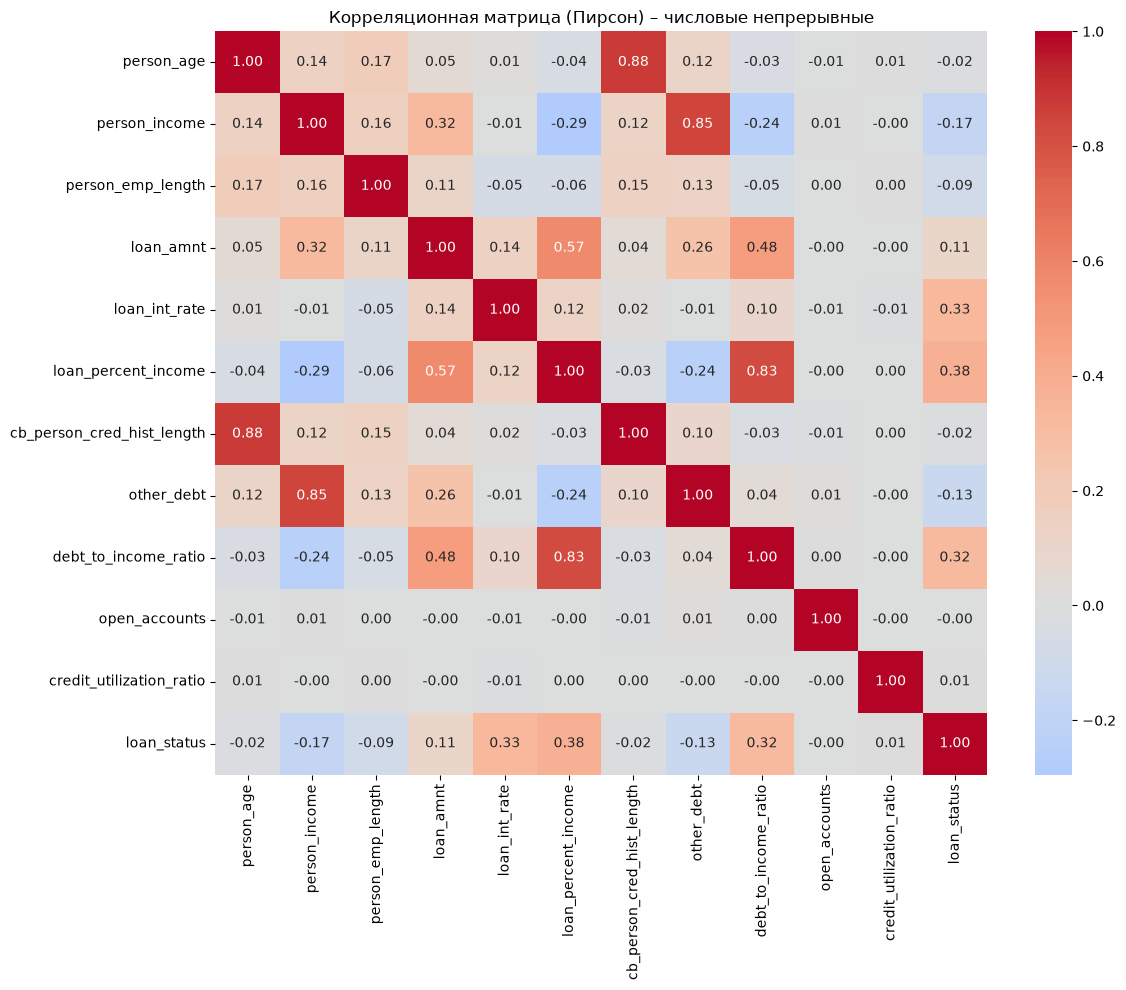

Матрица корреляции Пирсона:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,loan_status
person_age,1.000000,0.140497,0.170688,0.051751,0.011947,-0.041587,0.878094,0.117497,-0.034564,-0.005647,0.005990,-0.020687
person_income,0.140497,1.000000,0.155439,0.317497,-0.005636,-0.294558,0.123049,0.846712,-0.239011,0.006769,-0.002617,-0.168485
person_emp_length,0.170688,0.155439,1.000000,0.111820,-0.052798,-0.058515,0.147713,0.125917,-0.048689,0.000172,0.004293,-0.085613
loan_amnt,0.051751,0.317497,0.111820,1.000000,0.142462,0.572420,0.042240,0.263006,0.480988,-0.003742,-0.004350,0.105240
loan_int_rate,0.011947,-0.005636,-0.052798,0.142462,1.000000,0.120761,0.015895,-0.005135,0.102803,-0.006111,-0.014886,0.333634
loan_percent_income,-0.041587,-0.294558,-0.058515,0.572420,0.120761,1.000000,-0.031447,-0.239602,0.827874,-0.000866,0.001754,0.379250
cb_person_cred_hist_length,0.878094,0.123049,0.147713,0.042240,0.015895,-0.031447,1.000000,0.102021,-0.026673,-0.007048,0.001812,-0.015472
other_debt,0.117497,0.846712,0.125917,0.263006,-0.005135,-0.239602,0.102021,1.000000,0.041262,0.009038,-0.003569,-0.134762
debt_to_income_ratio,-0.034564,-0.239011,-0.048689,0.480988,0.102803,0.827874,-0.026673,0.041262,1.000000,0.003941,-0.001287,0.321400
open_accounts,-0.005647,0.006769,0.000172,-0.003742,-0.006111,-0.000866,-0.007048,0.009038,0.003941,1.000000,-0.003671,-0.002857


Корреляция Пирсона с целевой переменной:
loan_percent_income           0.379250
loan_int_rate                 0.333634
debt_to_income_ratio          0.321400
loan_amnt                     0.105240
credit_utilization_ratio      0.007260
open_accounts                -0.002857
cb_person_cred_hist_length   -0.015472
person_age                   -0.020687
person_emp_length            -0.085613
other_debt                   -0.134762
person_income                -0.168485
Name: loan_status, dtype: float64


In [8]:
# Анализ числовых непрерывных признаков

# Матрица корреляции Пирсона
corr_pearson = df[numeric_continuous + [target]].corr(method="pearson")

# Тепловая карта
plt.figure(figsize=(12, 10))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляционная матрица (Пирсон) – числовые непрерывные")
plt.tight_layout()
plt.show()

# Вывод матрицы корреляции
print("Матрица корреляции Пирсона:")
display(corr_pearson)

# Корреляция с целевой переменной
corr_with_target_pearson = corr_pearson[target].drop(target).sort_values(ascending=False)
print("Корреляция Пирсона с целевой переменной:")
print(corr_with_target_pearson)

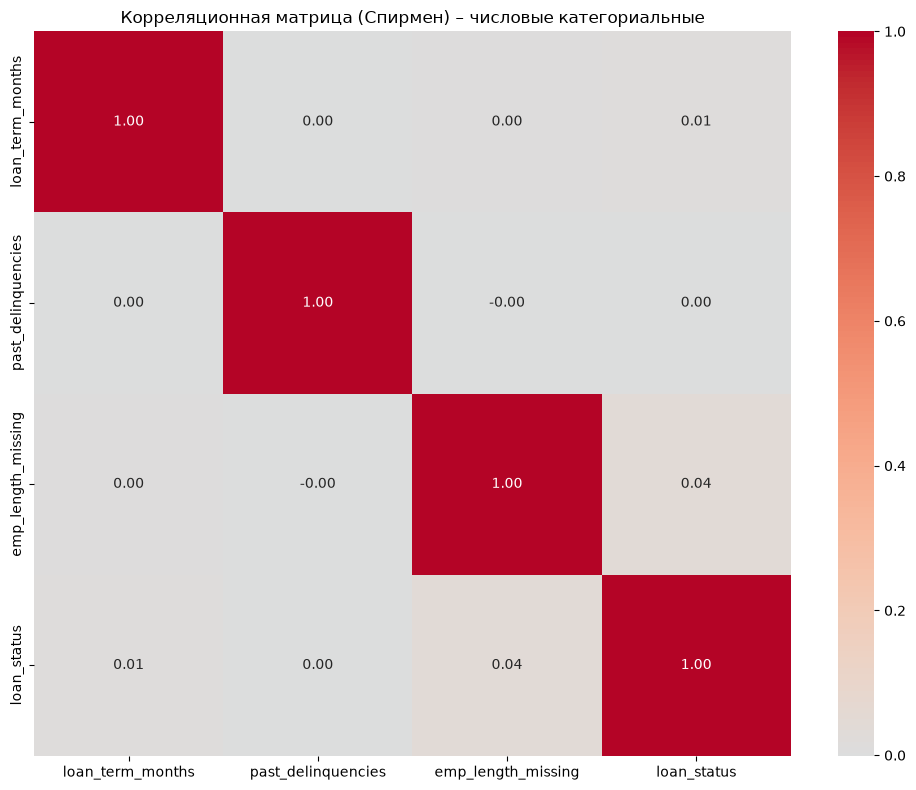

Матрица корреляции Спирмана:


,loan_term_months,past_delinquencies,emp_length_missing,loan_status
loan_term_months,1.000000,0.000712,0.004469,0.011126
past_delinquencies,0.000712,1.000000,-0.001015,0.000766
emp_length_missing,0.004469,-0.001015,1.000000,0.039437
loan_status,0.011126,0.000766,0.039437,1.000000


Корреляция Спирмена с целевой переменной:
emp_length_missing    0.039437
loan_term_months      0.011126
past_delinquencies    0.000766
Name: loan_status, dtype: float64


In [9]:
# Анализ числовых категориальных признаков

# Матрица корреляции Спирмана
corr_spearman = df[numeric_categorical + [target]].corr(method="spearman")

# Тепловая карта
plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляционная матрица (Спирмен) – числовые категориальные")
plt.tight_layout()
plt.show()

# Вывод матрицы корреляции
print("Матрица корреляции Спирмана:")
display(corr_spearman)

corr_with_target_spearman = corr_spearman[target].drop(target).sort_values(ascending=False)
print("Корреляция Спирмена с целевой переменной:")
print(corr_with_target_spearman)

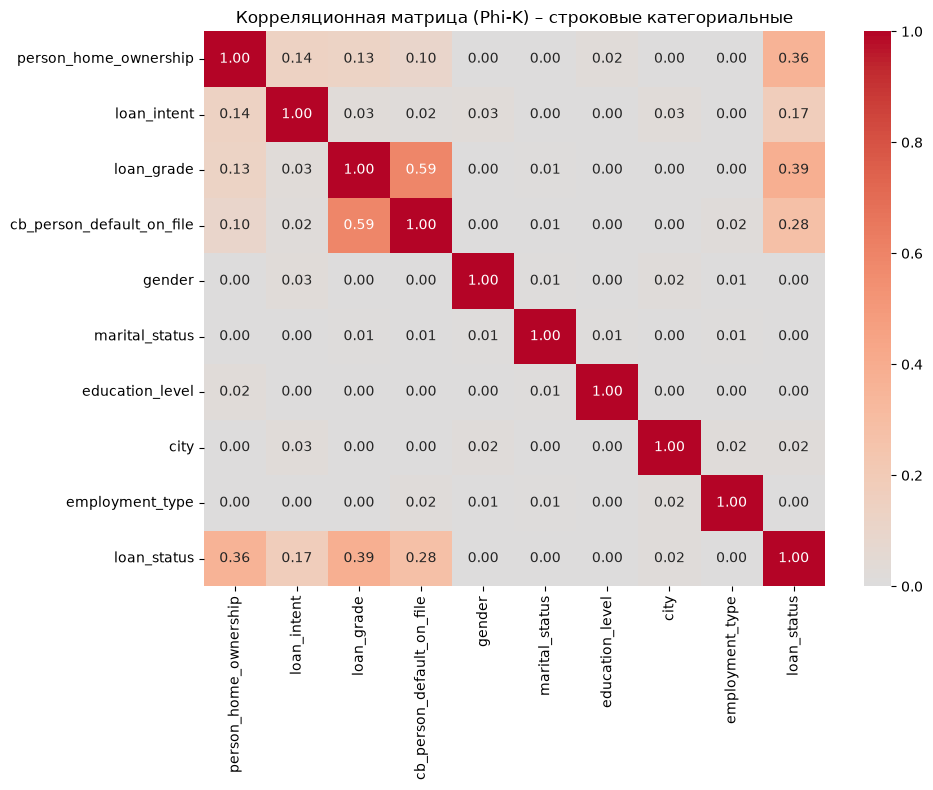

Матрица корреляции Phi-K:


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file,gender,marital_status,education_level,city,employment_type,loan_status
person_home_ownership,1.000000,0.135049,0.125073,0.097632,0.000000,0.000000,0.023645,0.000000,0.000000,0.361601
loan_intent,0.135049,1.000000,0.029184,0.016060,0.025369,0.000000,0.000000,0.031039,0.000000,0.174818
loan_grade,0.125073,0.029184,1.000000,0.588207,0.000000,0.011575,0.000000,0.000000,0.000000,0.387151
cb_person_default_on_file,0.097632,0.016060,0.588207,1.000000,0.000000,0.007388,0.000000,0.000000,0.023426,0.277213
gender,0.000000,0.025369,0.000000,0.000000,1.000000,0.010133,0.000000,0.018789,0.006385,0.000000
marital_status,0.000000,0.000000,0.011575,0.007388,0.010133,1.000000,0.013170,0.000000,0.009026,0.000000
education_level,0.023645,0.000000,0.000000,0.000000,0.000000,0.013170,1.000000,0.000000,0.000000,0.000000
city,0.000000,0.031039,0.000000,0.000000,0.018789,0.000000,0.000000,1.000000,0.019977,0.016698
employment_type,0.000000,0.000000,0.000000,0.023426,0.006385,0.009026,0.000000,0.019977,1.000000,0.000000
loan_status,0.361601,0.174818,0.387151,0.277213,0.000000,0.000000,0.000000,0.016698,0.000000,1.000000


Корреляция Phi-K с целевой переменной (строковые категориальные):
loan_grade                   0.387151
person_home_ownership        0.361601
cb_person_default_on_file    0.277213
loan_intent                  0.174818
city                         0.016698
gender                       0.000000
marital_status               0.000000
education_level              0.000000
employment_type              0.000000
Name: loan_status, dtype: float64


In [10]:
# Анализ категориальных признаков

# Матрица Phi-K
df_cat = df[categorical_str + [target]].astype(str)
corr_phik_cat = df_cat.phik_matrix()

# Тепловая карта
plt.figure(figsize=(10, 8))
sns.heatmap(corr_phik_cat, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляционная матрица (Phi-K) – строковые категориальные")
plt.tight_layout()
plt.show()

# Вывод матрицы корреляции
print("Матрица корреляции Phi-K:")
display(corr_phik_cat)

corr_with_target_phik_cat = corr_phik_cat[target].drop(target).sort_values(ascending=False)
print("Корреляция Phi-K с целевой переменной (строковые категориальные):")
print(corr_with_target_phik_cat)

### Выводы по анализу признаков

#### Числовые признаки (Пирсон)

**Сильные предикторы (положительная связь):**
- `loan_percent_income` (0.379) – доля кредита в доходе.
- `loan_int_rate` (0.334) – процентная ставка.
- `debt_to_income_ratio` (0.321) – долговая нагрузка.

**Сильные предикторы (отрицательная связь):**
- `person_income` (-0.168) – чем выше доход, тем ниже риск.
- `other_debt` (-0.135) – чем больше других долгов, тем ниже риск (парадокс: возможно, заёмщики с другими долгами имеют более высокий доход или более длинную кредитную историю).

**Слабые или нулевые:**
- `credit_utilization_ratio` (0.007)
- `open_accounts` (-0.003)
- `cb_person_cred_hist_length` (-0.015)
- `person_age` (-0.021)

**Мультиколлинеарность (сильная корреляция между признаками):**
- `person_age` и `cb_person_cred_hist_length` (0.878) – практически дублируют друг друга.
- `person_income` и `other_debt` (0.847) – высокий доход связан с большими долгами.
- `debt_to_income_ratio` и `loan_percent_income` (0.828) – оба отражают долговую нагрузку.
- `loan_amnt` и `loan_percent_income` (0.572) – большие кредиты дают большую долю в доходе.

**Вывод:** можно удалить один из дублирующихся признаков (`cb_person_cred_hist_length` или `person_age`), так как они почти идентичны. Также `debt_to_income_ratio` и `loan_percent_income` дублируют информацию.

---

#### Числовые категориальные признаки (Спирмен)

| Признак | Корреляция с `loan_status` |
|---------|----------------------------|
| `emp_length_missing` | 0.039 |
| `loan_term_months` | 0.011 |
| `past_delinquencies` | 0.001 |

**Вывод:** все три признака имеют очень слабую связь с целевой переменной. `past_delinquencies` практически не коррелирует, хотя в EDA есть разница в долях дефолтов. Это говорит о том, что связь нелинейная — можно создать бинарный признак `has_delinquency` (1, если было хотя бы 1 просрочка) или сгруппировать значения.

---

#### Строковые категориальные признаки (Phi-K)

| Признак | Корреляция с `loan_status` |
|---------|----------------------------|
| `loan_grade` | 0.387 |
| `person_home_ownership` | 0.362 |
| `cb_person_default_on_file` | 0.277 |
| `loan_intent` | 0.175 |
| `city` | 0.017 |
| `gender`, `marital_status`, `education_level`, `employment_type` | 0.000 |

**Вывод:** сильные категориальные признаки — `loan_grade`, `person_home_ownership`, `cb_person_default_on_file`, `loan_intent`. Остальные практически не влияют на целевую переменную.

## Создание новых признаков

### Взаимодействие сильных признаков

In [11]:
# Отношение долговой нагрузки к доле кредита в доходе
df["dti_loan_pct_ratio"] = df["debt_to_income_ratio"] / (df["loan_percent_income"] + 0.001)

# Разница между доходом и другими долгами
df["income_debt_balance"] = df["person_income"] - df["other_debt"]

# Отклонение ставки от среднего по классу кредита
avg_rate_by_grade = df.groupby("loan_grade")["loan_int_rate"].transform("mean")
df["rate_grade_deviation"] = df["loan_int_rate"] - avg_rate_by_grade

print("Созданы признаки взаимодействия числовых переменных:")
display(df[["dti_loan_pct_ratio", "income_debt_balance", "rate_grade_deviation"]].head())

Созданы признаки взаимодействия числовых переменных:


,dti_loan_pct_ratio,income_debt_balance,rate_grade_deviation
1,2.689566,7992.197206,0.145017
2,1.506952,6839.494367,-0.595245
3,1.212038,58344.713850,1.764755
4,1.688980,38773.846560,0.804755
5,1.896149,7688.258866,-0.202835


### Бинарные флаги

In [12]:
# Пороги на основе 75-го перцентиля
threshold_debt = df["debt_to_income_ratio"].quantile(0.75)
threshold_loan_pct = df["loan_percent_income"].quantile(0.75)
threshold_rate = df["loan_int_rate"].quantile(0.75)

df["is_high_debt"] = (df["debt_to_income_ratio"] > threshold_debt).astype(int)
df["is_high_loan_pct"] = (df["loan_percent_income"] > threshold_loan_pct).astype(int)
df["is_high_rate"] = (df["loan_int_rate"] > threshold_rate).astype(int)

print("Созданы бинарные индикаторы риска (пороги = 75-й перцентиль):")
print(f"Порог debt_to_income_ratio: {threshold_debt:.3f}")
print(f"Порог loan_percent_income: {threshold_loan_pct:.3f}")
print(f"Порог loan_int_rate: {threshold_rate:.3f}")

display(df[["is_high_debt", "is_high_loan_pct", "is_high_rate"]].head())

Созданы бинарные индикаторы риска (пороги = 75-й перцентиль):
Порог debt_to_income_ratio: 0.423
Порог loan_percent_income: 0.230
Порог loan_int_rate: 13.480


,is_high_debt,is_high_loan_pct,is_high_rate
1,0,0,0
2,1,1,0
3,1,1,1
4,1,1,1
5,1,1,0


### Агрегированные признаки

In [13]:
# Средний DTI по городу
city_avg_dti = df.groupby("city")["debt_to_income_ratio"].mean().to_dict()
df["city_avg_dti"] = df["city"].map(city_avg_dti)

# Средний loan_percent_income по городу
city_avg_loan_pct = df.groupby("city")["loan_percent_income"].mean().to_dict()
df["city_avg_loan_pct"] = df["city"].map(city_avg_loan_pct)

print("Созданы агрегированные признаки по городу:")
display(df[["city_avg_dti", "city_avg_loan_pct"]].head())

Созданы агрегированные признаки по городу:


,city_avg_dti,city_avg_loan_pct
1,0.345999,0.172474
2,0.342457,0.166646
3,0.344076,0.169715
4,0.343929,0.171304
5,0.344580,0.168039


### Комбинации категорий

In [14]:
df["grade_ownership"] = df["loan_grade"].astype(str) + "_" + df["person_home_ownership"].astype(str)
df["default_grade"] = df["cb_person_default_on_file"].astype(str) + "_" + df["loan_grade"].astype(str)

print("Созданы комбинации категориальных признаков:")
display(df[["grade_ownership", "default_grade"]].head())

Созданы комбинации категориальных признаков:


,grade_ownership,default_grade
1,B_OWN,N_B
2,C_MORTGAGE,N_C
3,C_RENT,N_C
4,C_RENT,Y_C
5,A_OWN,N_A


## Анализ новых признаков

### Корреляция числовых новых признаков

In [15]:
new_numeric = [
    "dti_loan_pct_ratio", "income_debt_balance", "rate_grade_deviation",
    "is_high_debt", "is_high_loan_pct", "is_high_rate",
    "city_avg_dti", "city_avg_loan_pct"
]

corr_new = df[new_numeric + ["loan_status"]].corr(method="pearson")["loan_status"].drop("loan_status").sort_values(ascending=False)
print("Корреляция Пирсона (новые числовые признаки):")
print(corr_new)

Корреляция Пирсона (новые числовые признаки):
is_high_loan_pct        0.333857
is_high_rate            0.320723
is_high_debt            0.287719
rate_grade_deviation    0.017667
city_avg_dti            0.014020
city_avg_loan_pct       0.011043
dti_loan_pct_ratio     -0.084248
income_debt_balance    -0.168914
Name: loan_status, dtype: float64


### Корреляция категориальных новых признаков (Phi-K)

In [16]:
new_cat = ["grade_ownership", "default_grade"]
df_cat_new = df[new_cat + ["loan_status"]].astype(str)
corr_phik_new = df_cat_new.phik_matrix()
print("\nКорреляция Phi-K (новые категориальные признаки):")
print(corr_phik_new["loan_status"].drop("loan_status").sort_values(ascending=False))


Корреляция Phi-K (новые категориальные признаки):
grade_ownership    0.551498
default_grade      0.531550
Name: loan_status, dtype: float64


### Корреляционная матрица для числовых признаков

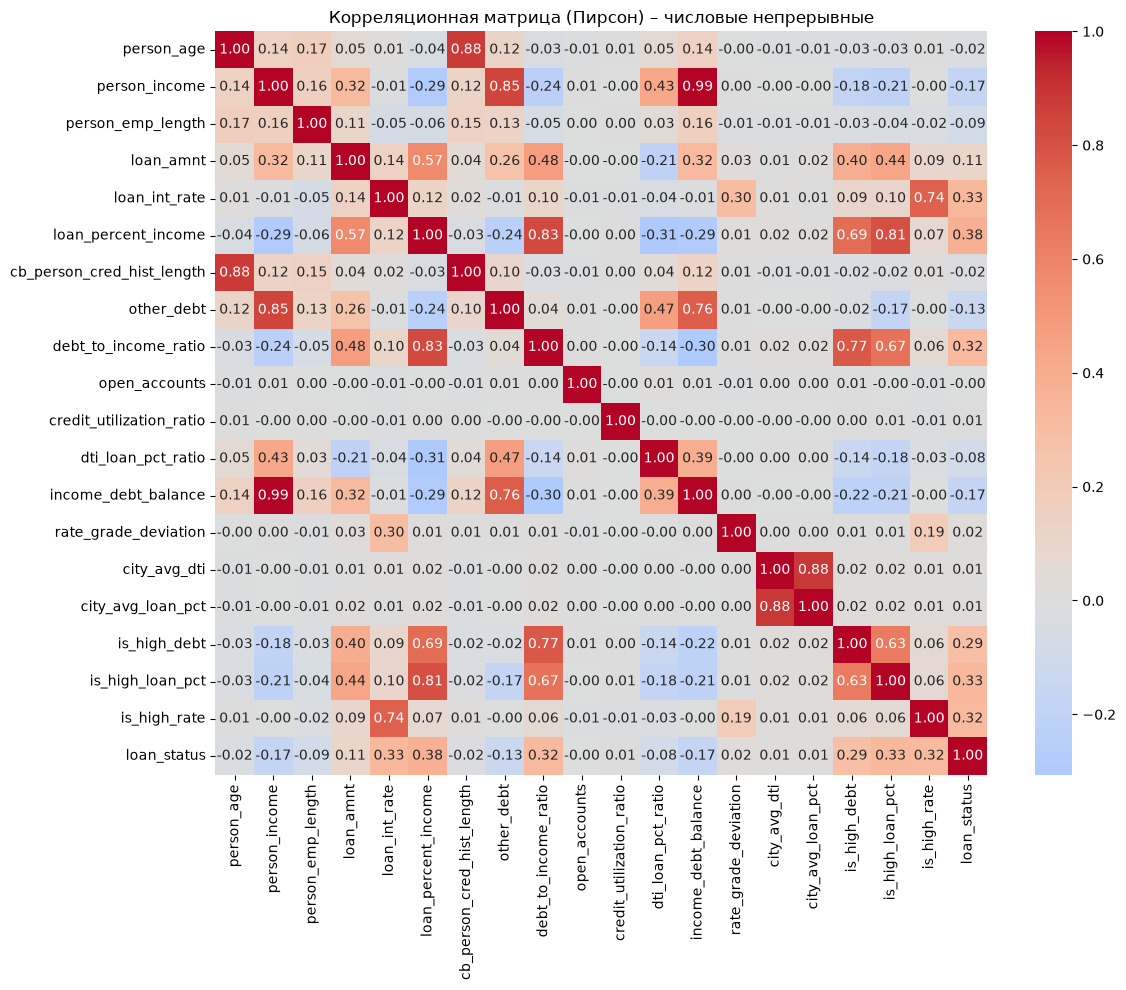

Корреляционная матрица для числовых признаков:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,dti_loan_pct_ratio,income_debt_balance,rate_grade_deviation,city_avg_dti,city_avg_loan_pct,is_high_debt,is_high_loan_pct,is_high_rate,loan_status
person_age,1.000000,0.140497,0.170688,0.051751,0.011947,-0.041587,0.878094,0.117497,-0.034564,-0.005647,0.005990,0.049787,0.139518,-0.000461,-0.008932,-0.009987,-0.029534,-0.027638,0.009956,-0.020687
person_income,0.140497,1.000000,0.155439,0.317497,-0.005636,-0.294558,0.123049,0.846712,-0.239011,0.006769,-0.002617,0.427284,0.990319,0.003260,-0.003645,-0.000470,-0.184654,-0.210334,-0.003865,-0.168485
person_emp_length,0.170688,0.155439,1.000000,0.111820,-0.052798,-0.058515,0.147713,0.125917,-0.048689,0.000172,0.004293,0.032952,0.155420,-0.012118,-0.013466,-0.012265,-0.028192,-0.036846,-0.020759,-0.085613
loan_amnt,0.051751,0.317497,0.111820,1.000000,0.142462,0.572420,0.042240,0.263006,0.480988,-0.003742,-0.004350,-0.210890,0.315942,0.029682,0.008991,0.015295,0.396172,0.440902,0.090213,0.105240
loan_int_rate,0.011947,-0.005636,-0.052798,0.142462,1.000000,0.120761,0.015895,-0.005135,0.102803,-0.006111,-0.014886,-0.042449,-0.005487,0.298443,0.010708,0.008474,0.092448,0.100220,0.740068,0.333634
loan_percent_income,-0.041587,-0.294558,-0.058515,0.572420,0.120761,1.000000,-0.031447,-0.239602,0.827874,-0.000866,0.001754,-0.305877,-0.294264,0.011606,0.021619,0.024456,0.694024,0.808425,0.070246,0.379250
cb_person_cred_hist_length,0.878094,0.123049,0.147713,0.042240,0.015895,-0.031447,1.000000,0.102021,-0.026673,-0.007048,0.001812,0.040466,0.122422,0.006417,-0.005718,-0.009278,-0.023236,-0.019216,0.012479,-0.015472
other_debt,0.117497,0.846712,0.125917,0.263006,-0.005135,-0.239602,0.102021,1.000000,0.041262,0.009038,-0.003569,0.474187,0.764661,0.005703,-0.000352,-0.000596,-0.024251,-0.170403,-0.003750,-0.134762
debt_to_income_ratio,-0.034564,-0.239011,-0.048689,0.480988,0.102803,0.827874,-0.026673,0.041262,1.000000,0.003941,-0.001287,-0.141143,-0.300261,0.009651,0.023280,0.020579,0.774717,0.668977,0.060885,0.321400
open_accounts,-0.005647,0.006769,0.000172,-0.003742,-0.006111,-0.000866,-0.007048,0.009038,0.003941,1.000000,-0.003671,0.014228,0.005840,-0.006040,0.003255,0.004422,0.005716,-0.002969,-0.009699,-0.002857


Корреляция Пирсона с целевой переменной:
loan_percent_income           0.379250
is_high_loan_pct              0.333857
loan_int_rate                 0.333634
debt_to_income_ratio          0.321400
is_high_rate                  0.320723
is_high_debt                  0.287719
loan_amnt                     0.105240
rate_grade_deviation          0.017667
city_avg_dti                  0.014020
city_avg_loan_pct             0.011043
credit_utilization_ratio      0.007260
open_accounts                -0.002857
cb_person_cred_hist_length   -0.015472
person_age                   -0.020687
dti_loan_pct_ratio           -0.084248
person_emp_length            -0.085613
other_debt                   -0.134762
person_income                -0.168485
income_debt_balance          -0.168914
Name: loan_status, dtype: float64


In [17]:
numeric_continuous = [
    "person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length", "other_debt",
    "debt_to_income_ratio", "open_accounts", "credit_utilization_ratio", "dti_loan_pct_ratio",
    "income_debt_balance", "rate_grade_deviation", "city_avg_dti", "city_avg_loan_pct",
    "is_high_debt", "is_high_loan_pct", "is_high_rate"
]

corr_pearson = df[numeric_continuous + [target]].corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляционная матрица (Пирсон) – числовые непрерывные")
plt.tight_layout()
plt.show()

# Корреляционная матрица для числовых признаков
print("Корреляционная матрица для числовых признаков:")
display(corr_pearson)

corr_with_target_pearson = corr_pearson[target].drop(target).sort_values(ascending=False)
print("Корреляция Пирсона с целевой переменной:")
print(corr_with_target_pearson)

### Корреляционная матрица для категориальных признаков

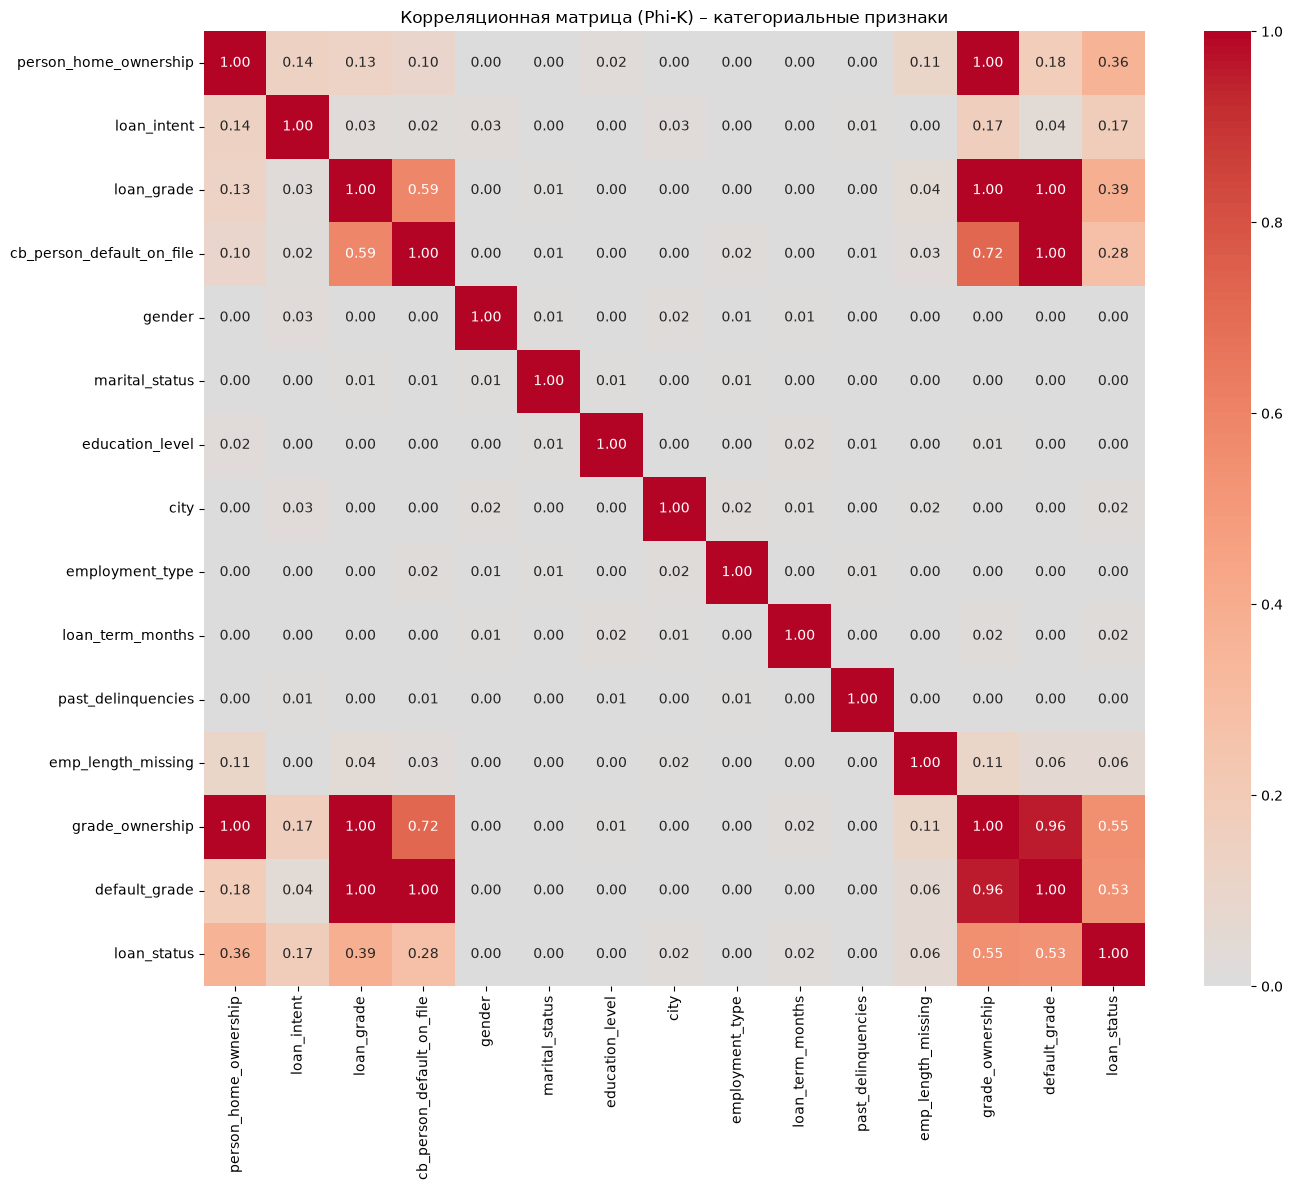

Корреляционная матрица для категориальных признаков:


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file,gender,marital_status,education_level,city,employment_type,loan_term_months,past_delinquencies,emp_length_missing,grade_ownership,default_grade,loan_status
person_home_ownership,1.000000,0.135049,0.125073,0.097632,0.000000,0.000000,0.023645,0.000000,0.000000,0.000000,0.000000,0.109017,1.000000,0.182788,0.361601
loan_intent,0.135049,1.000000,0.029184,0.016060,0.025369,0.000000,0.000000,0.031039,0.000000,0.000000,0.008259,0.000000,0.167706,0.042585,0.174818
loan_grade,0.125073,0.029184,1.000000,0.588207,0.000000,0.011575,0.000000,0.000000,0.000000,0.000000,0.000000,0.042244,1.000000,1.000000,0.387151
cb_person_default_on_file,0.097632,0.016060,0.588207,1.000000,0.000000,0.007388,0.000000,0.000000,0.023426,0.003313,0.006312,0.030776,0.719209,1.000000,0.277213
gender,0.000000,0.025369,0.000000,0.000000,1.000000,0.010133,0.000000,0.018789,0.006385,0.010038,0.000000,0.000000,0.000000,0.000000,0.000000
marital_status,0.000000,0.000000,0.011575,0.007388,0.010133,1.000000,0.013170,0.000000,0.009026,0.000000,0.000000,0.002948,0.000000,0.000000,0.000000
education_level,0.023645,0.000000,0.000000,0.000000,0.000000,0.013170,1.000000,0.000000,0.000000,0.016421,0.006919,0.000000,0.013991,0.000000,0.000000
city,0.000000,0.031039,0.000000,0.000000,0.018789,0.000000,0.000000,1.000000,0.019977,0.013047,0.000000,0.015265,0.000000,0.000000,0.016698
employment_type,0.000000,0.000000,0.000000,0.023426,0.006385,0.009026,0.000000,0.019977,1.000000,0.000000,0.013530,0.000000,0.000000,0.000000,0.000000
loan_term_months,0.000000,0.000000,0.000000,0.003313,0.010038,0.000000,0.016421,0.013047,0.000000,1.000000,0.000000,0.000000,0.015714,0.000000,0.020213


Корреляция Phi-K с целевой переменной:
grade_ownership              0.551498
default_grade                0.531550
loan_grade                   0.387151
person_home_ownership        0.361601
cb_person_default_on_file    0.277213
loan_intent                  0.174818
emp_length_missing           0.060936
loan_term_months             0.020213
city                         0.016698
gender                       0.000000
marital_status               0.000000
education_level              0.000000
employment_type              0.000000
past_delinquencies           0.000000
Name: loan_status, dtype: float64


In [18]:
categorical = [
    "person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file",
    "gender", "marital_status", "education_level", "city",
    "employment_type", "loan_term_months", "past_delinquencies", "emp_length_missing",
    "grade_ownership", "default_grade"
]

corr_phik = df[categorical + [target]].astype(str).phik_matrix()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_phik, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляционная матрица (Phi-K) – категориальные признаки")
plt.tight_layout()
plt.show()

# Корреляционная матрица для категориальных признаков
print("Корреляционная матрица для категориальных признаков:")
display(corr_phik)

corr_with_target_phik = corr_phik[target].drop(target).sort_values(ascending=False)
print("Корреляция Phi-K с целевой переменной:")
print(corr_with_target_phik)

## Итоговый вывод по новым признакам

### Числовые признаки (Пирсон)

#### Лучшие новые числовые признаки

| Признак | Корреляция | Комментарий |
|---------|------------|-------------|
| `is_high_loan_pct` | **0.334** | ✅ Отличный бинарный индикатор. Почти повторяет силу `loan_percent_income` (0.379). |
| `is_high_rate` | **0.321** | ✅ Отличный бинарный индикатор. Практически повторяет `loan_int_rate` (0.334). |
| `is_high_debt` | **0.288** | ✅ Хороший бинарный индикатор. Близок к `debt_to_income_ratio` (0.321). |

**Вывод:** бинарные флаги на основе 75-го перцентиля оказались очень сильными. Их можно использовать как самостоятельные признаки или как замену исходным непрерывным.

#### Средние новые признаки

| Признак | Корреляция | Комментарий |
|---------|------------|-------------|
| `income_debt_balance` | -0.169 | Средняя отрицательная связь, аналогична `person_income`. Не даёт нового сигнала. |
| `dti_loan_pct_ratio` | -0.084 | Слабая отрицательная связь. Не показал ожидаемой силы. |

#### Слабые / бесполезные новые признаки

| Признак | Корреляция | Комментарий |
|---------|------------|-------------|
| `rate_grade_deviation` | 0.018 | 🔴 Очень слабая. Отклонение ставки от среднего по классу не даёт сигнала. |
| `city_avg_dti` | 0.014 | 🔴 Очень слабая. Средний DTI по городу почти не связан с риском. |
| `city_avg_loan_pct` | 0.011 | 🔴 Очень слабая. Аналогично. |

**Вывод:** агрегированные признаки по городу не показали значимой связи. Возможно, город сам по себе слишком слабый признак, и агрегация не усилила сигнал. Их можно исключить.

---

### Категориальные признаки (Phi-K)

#### Новые категориальные признаки

| Признак | Корреляция | Комментарий |
|---------|------------|-------------|
| `grade_ownership` | **0.551** | ✅ **Очень сильный.** Комбинация `loan_grade` и `person_home_ownership` дала мощный сигнал. |
| `default_grade` | **0.532** | ✅ **Очень сильный.** Комбинация `cb_person_default_on_file` и `loan_grade` также очень сильна. |

**Вывод:** комбинации сильных категорий дают синергетический эффект. Эти признаки **обязательно** должны быть включены в модель.

#### Исходные категориальные признаки

| Признак | Корреляция |
|---------|------------|
| `loan_grade` | 0.387 |
| `person_home_ownership` | 0.362 |
| `cb_person_default_on_file` | 0.277 |
| `loan_intent` | 0.175 |
| `emp_length_missing` | 0.061 |
| `loan_term_months` | 0.020 |
| `city` | 0.017 |

**Вывод:** новые комбинированные признаки значительно превосходят исходные по силе связи.

#### Бесполезные категориальные признаки

| Признак | Корреляция |
|---------|------------|
| `gender` | 0.000 |
| `marital_status` | 0.000 |
| `education_level` | 0.000 |
| `employment_type` | 0.000 |
| `past_delinquencies` | 0.000 |

**Вывод:** эти признаки не имеют никакой связи с целевой переменной и могут быть удалены.

---

### Итоговый список признаков для моделирования

#### ✅ Оставить (сильные и полезные)

**Числовые:**
- `loan_percent_income` (или `is_high_loan_pct`)
- `loan_int_rate` (или `is_high_rate`)
- `debt_to_income_ratio` (или `is_high_debt`)
- `person_income` (или `income_debt_balance`)
- `loan_amnt`
- `person_age`
- `cb_person_cred_hist_length`
- `person_emp_length`
- `other_debt`

**Категориальные (для CatBoost — как строки):**
- `loan_grade` (можно заменить на `grade_ownership` или `default_grade`)
- `person_home_ownership` (можно заменить на `grade_ownership`)
- `cb_person_default_on_file` (можно заменить на `default_grade`)
- `loan_intent`
- `city` (можно оставить, но он слабый)
- `emp_length_missing`
- `loan_term_months`
- `grade_ownership`
- `default_grade`

#### ❌ Удалить (слабые / бесполезные)

- `gender`
- `marital_status`
- `education_level`
- `employment_type`
- `past_delinquencies`
- `dti_loan_pct_ratio`
- `rate_grade_deviation`
- `city_avg_dti`
- `city_avg_loan_pct`
- `open_accounts` (очень слабая корреляция)
- `credit_utilization_ratio` (очень слабая)